In [1]:
import numpy as np
import gudhi as gd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.spatial import distance_matrix

# **Comparación con Complejos Testigos**

/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (52). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (53). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (54). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (55). Possibly due to duplicate points in X.
  return fit_method(estimato

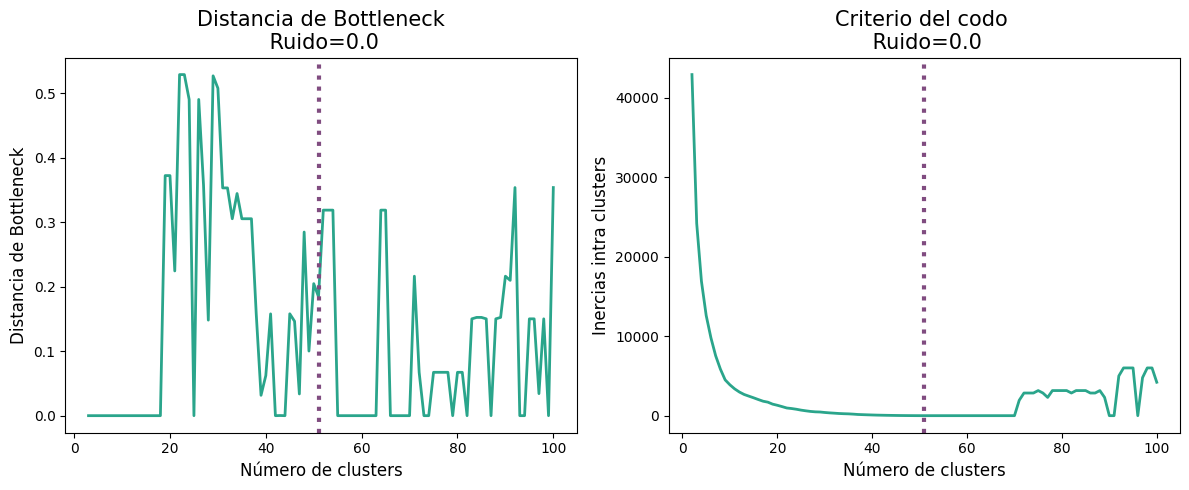

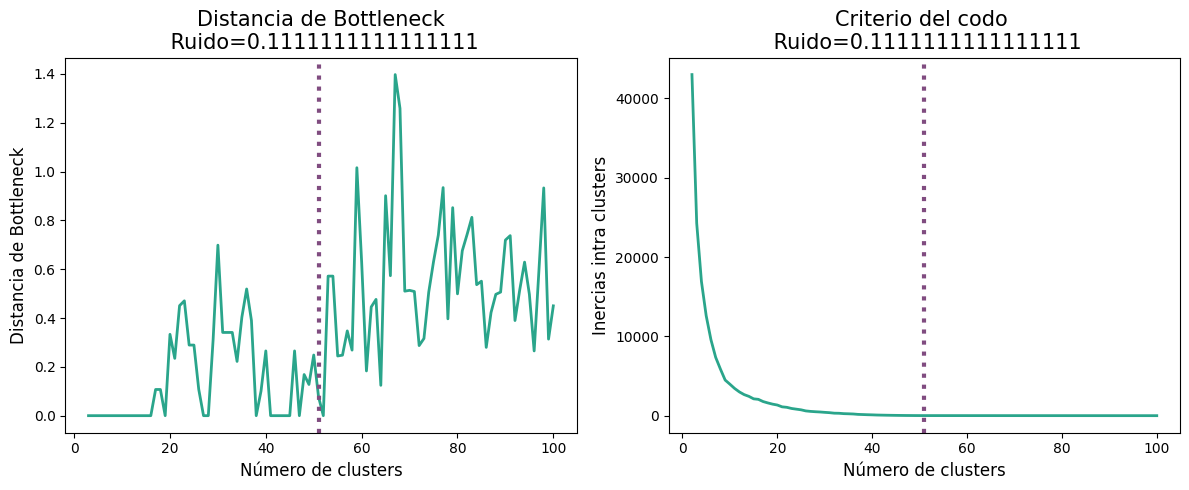

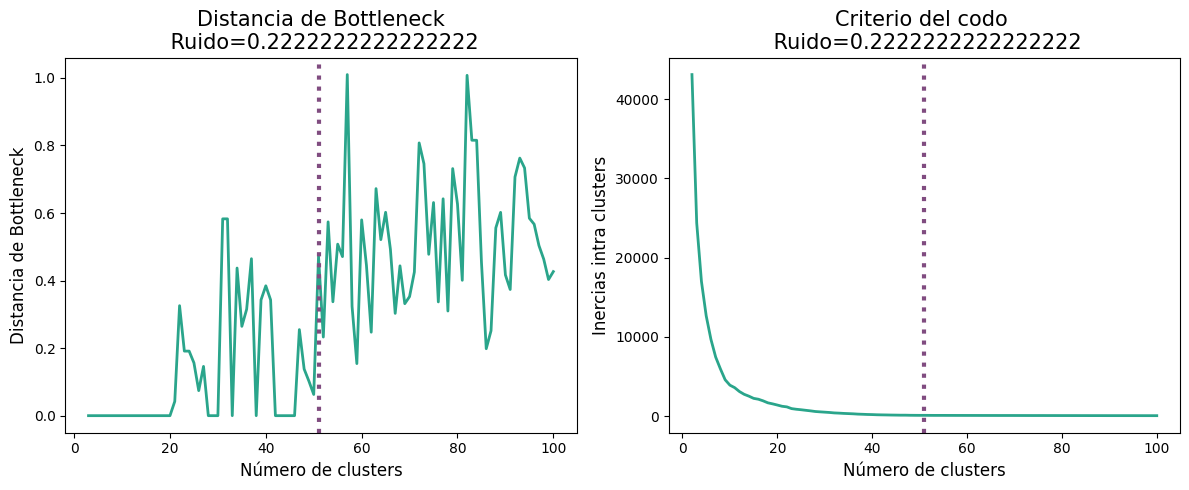

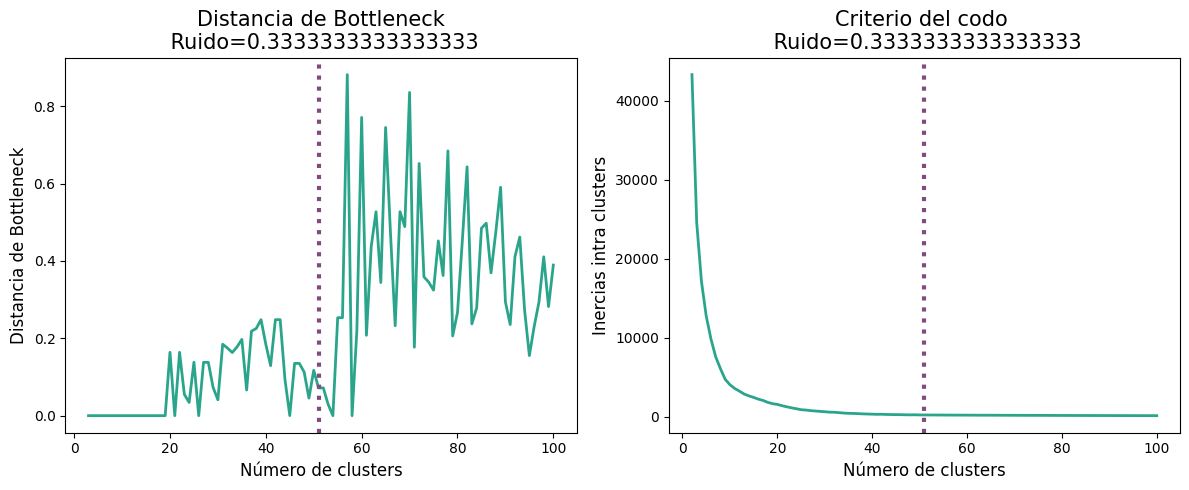

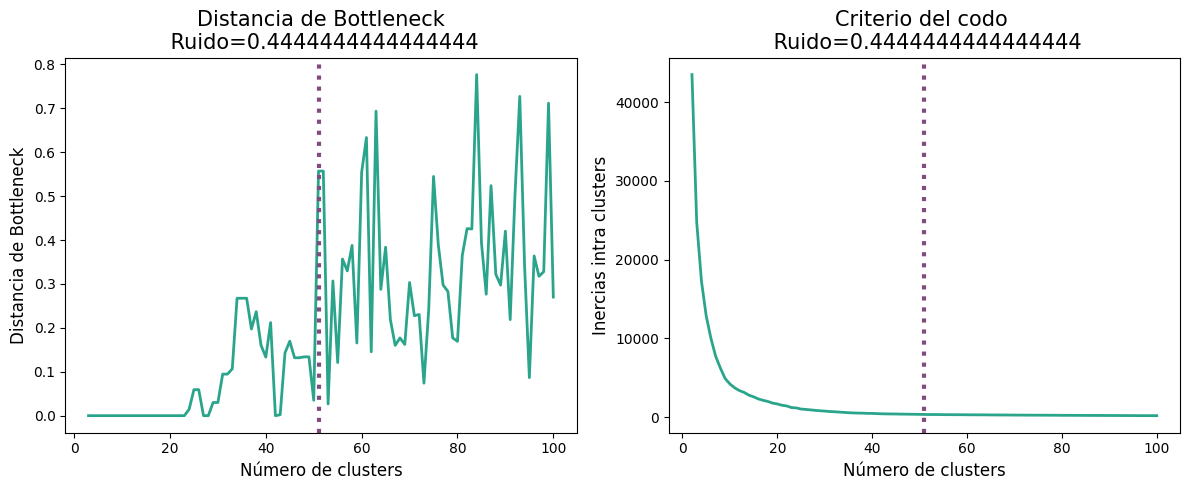

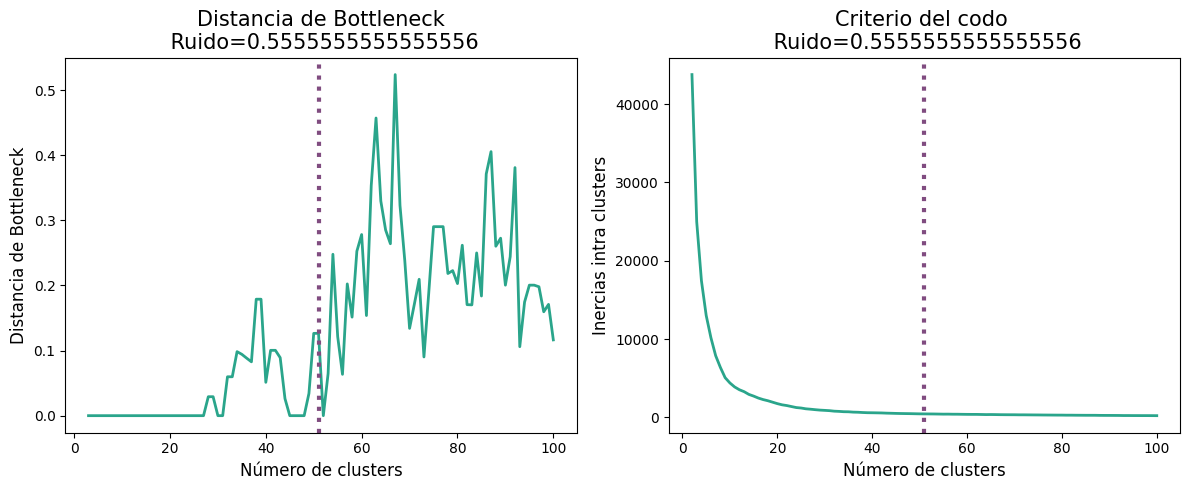

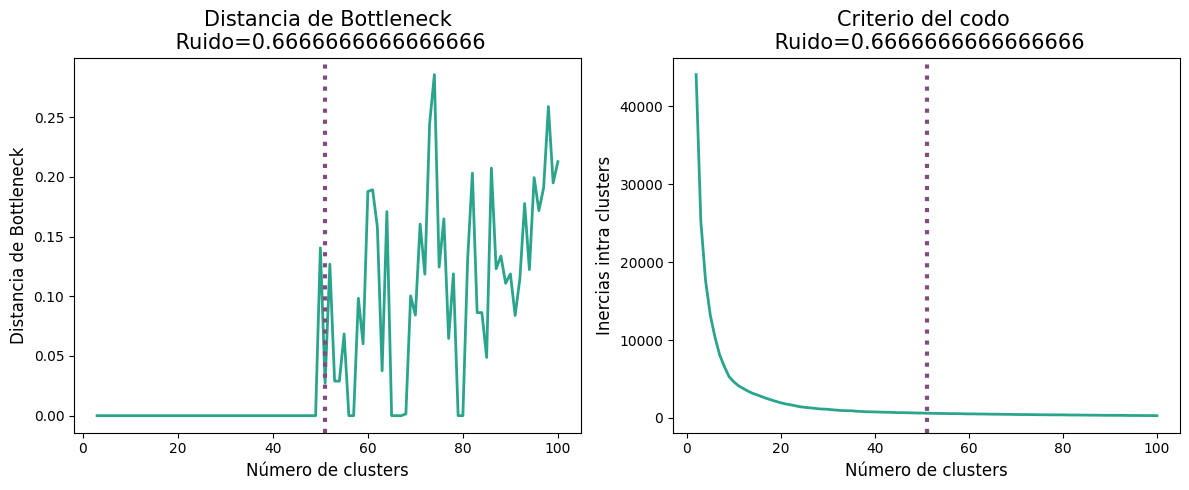

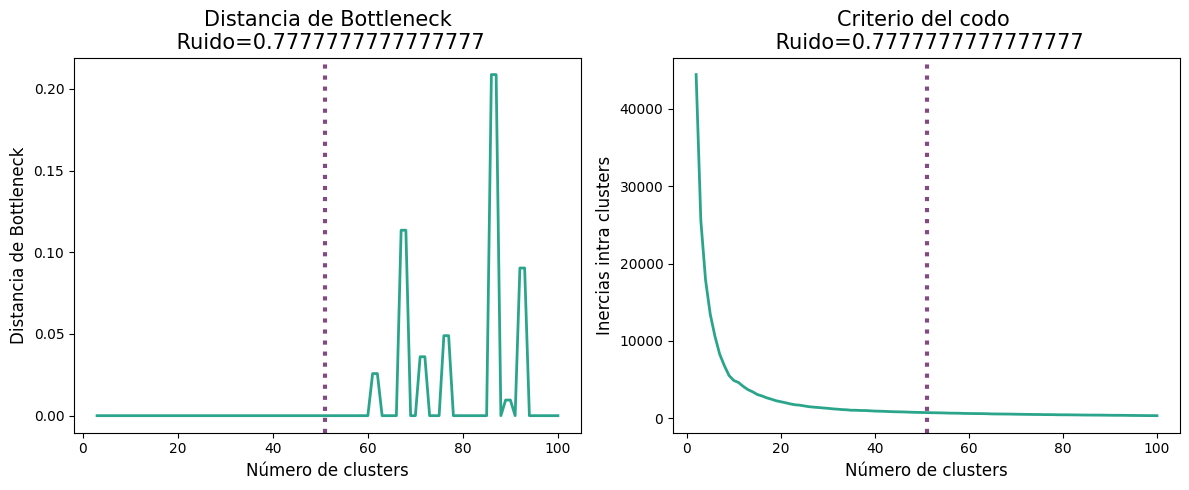

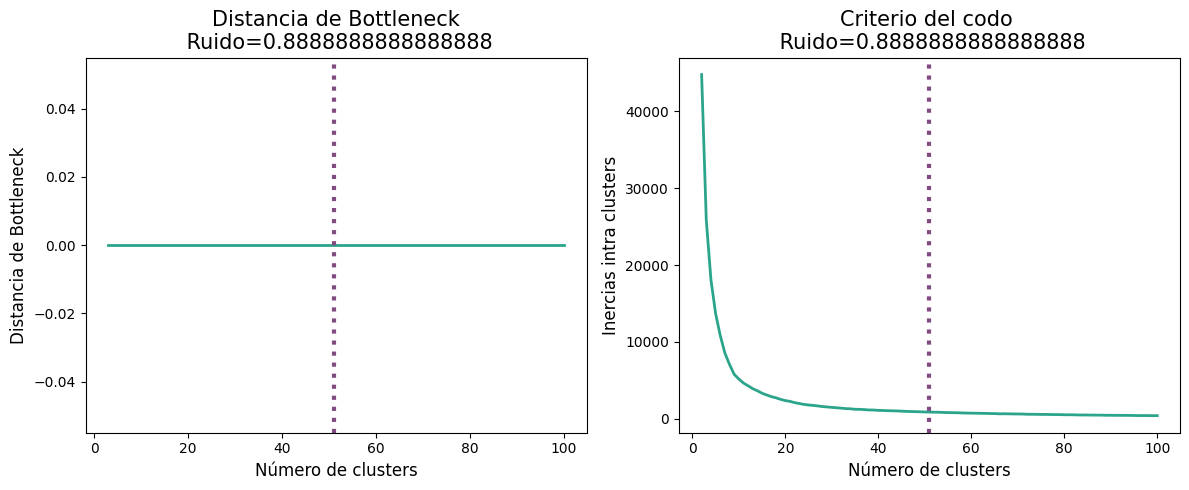

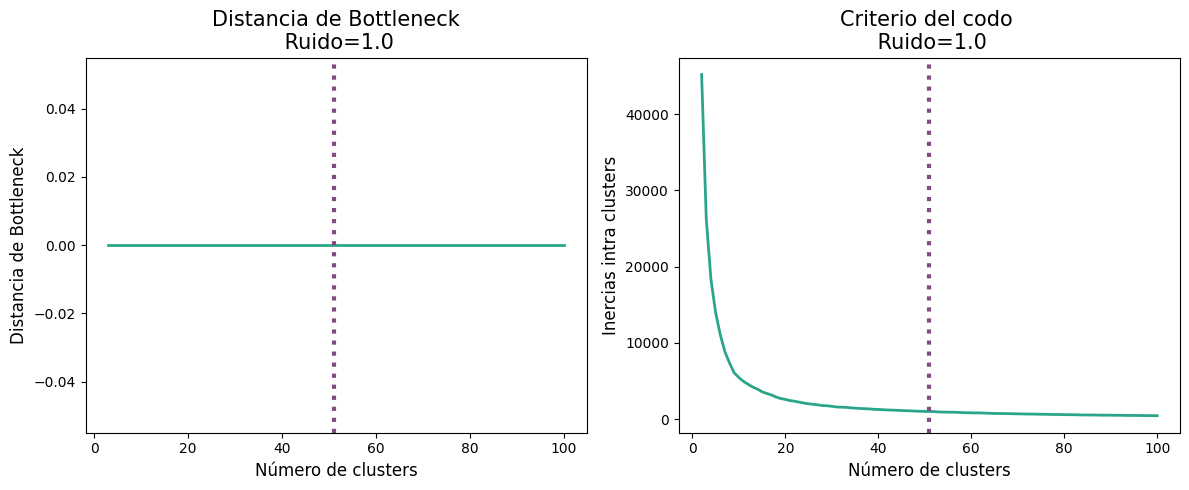

In [5]:
num_pruebas=10
num_clusters=51
num_puntos=1000
max_k = 100
ruido=np.linspace(0,1,num_pruebas)

for j in range(len(ruido)): 

    Datos,y=make_blobs(n_samples=num_puntos, centers=num_clusters, n_features=2, random_state=5, cluster_std=ruido[j])

    X=Datos
    inercias = []
    bottleneck_dists = []
    prev_diag = None
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        landmarks = kmeans.cluster_centers_
        inercias.append(kmeans.inertia_)
        
        dist_matrix = distance_matrix(landmarks, Datos)
        gudhi_table = []
        for t in range(dist_matrix.shape[1]):
            distances_to_witness = dist_matrix[:, t]
            
            witness_entries = [
                (idx, dist) for idx, dist in enumerate(distances_to_witness)
            ]

            witness_entries.sort(key=lambda x: x[1])
            gudhi_table.append(witness_entries)
        
        Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
        simplex_tree = Wt.create_simplex_tree(max_alpha_square=200, limit_dimension=1)
        diag = simplex_tree.persistence()
        aux = simplex_tree.persistence_intervals_in_dimension(0) 
        
        if prev_diag is not None:
            dist_b = gd.bottleneck_distance(prev_diag, aux)
            bottleneck_dists.append(dist_b)
        
        prev_diag = aux
        
    plt.figure(figsize=(12, 5))  # Ancho 12 pulgadas, alto 5 pulgadas

    # sumas_dist=[]
    # sumas_dist_prev=0
    # for i in range(0,len(bottleneck_dists)):
    #     aux=sumas_dist_prev+bottleneck_dists[i]
    #     sumas_dist_prev=aux
    #     sumas_dist.append(aux)

    plt.subplot(1,2,1)
    # plt.plot(list(range(3, max_k+1)), sumas_dist)
    plt.plot(list(range(3, max_k+1)), bottleneck_dists, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Distancia de Bottleneck\n Ruido={ruido[j]}', fontsize=15)  
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
    plt.subplot(1,2,2)
    plt.plot(list(range(2, max_k+1)), inercias, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Criterio del codo \n Ruido={ruido[j]}', fontsize=15)
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Inercias intra clusters', fontsize=12)
    
    plt.tight_layout()  
    plt.savefig(f"Witness_{j}.png", dpi=300, bbox_inches='tight')
    plt.show()

# **Comparación con Complejos de Vietoris-Rips**

/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (52). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (53). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (54). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (55). Possibly due to duplicate points in X.
  return fit_method(estimato

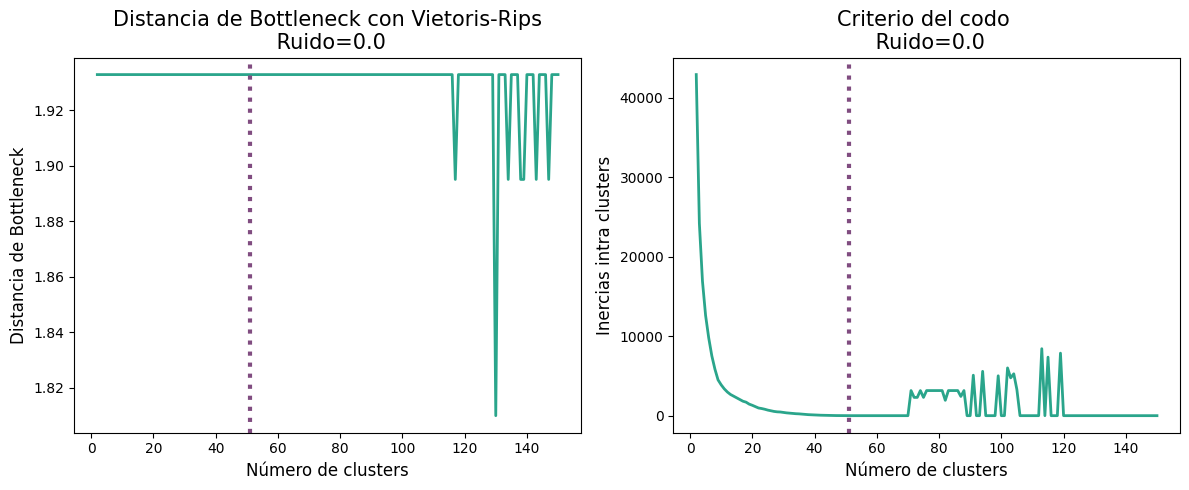

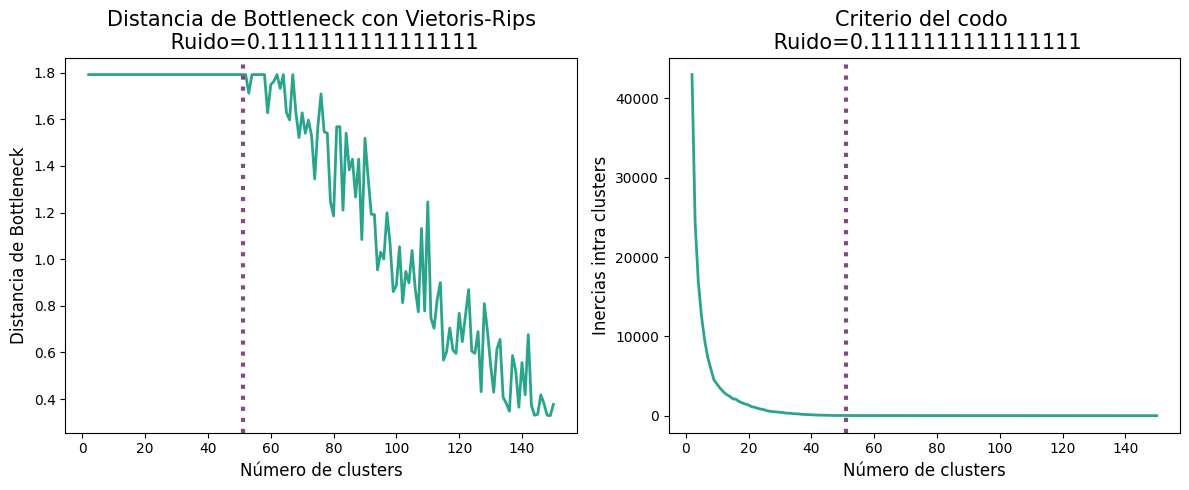

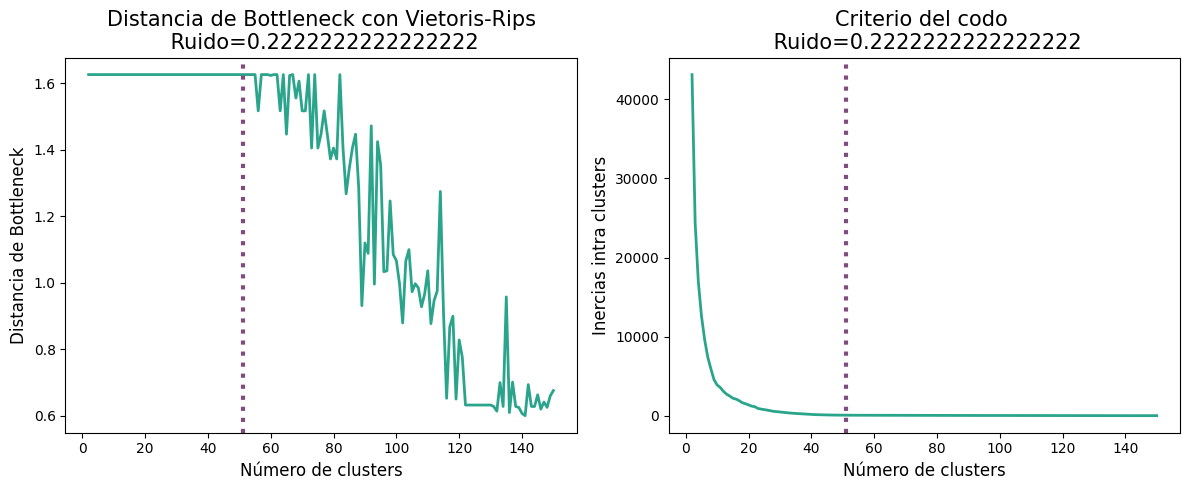

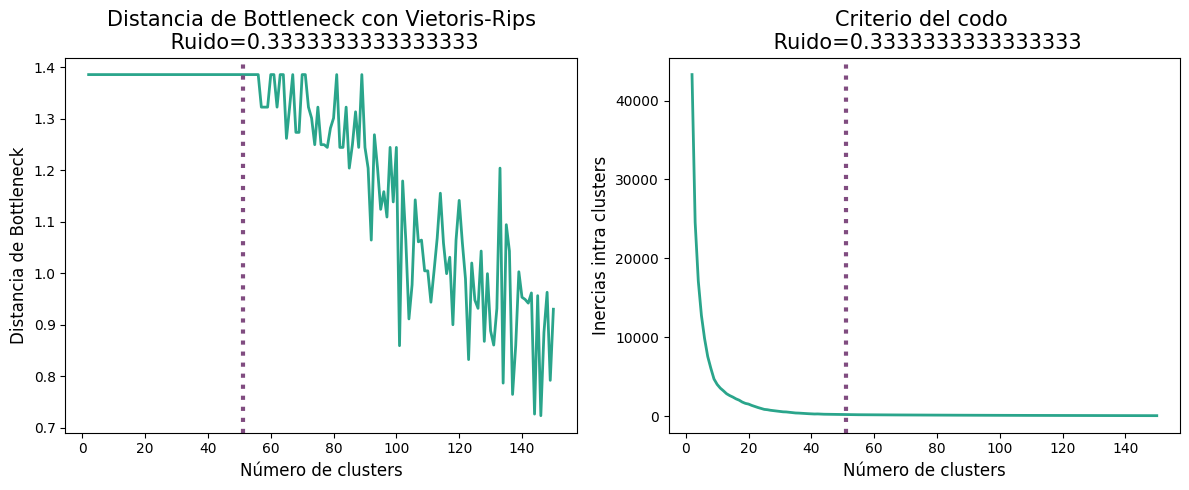

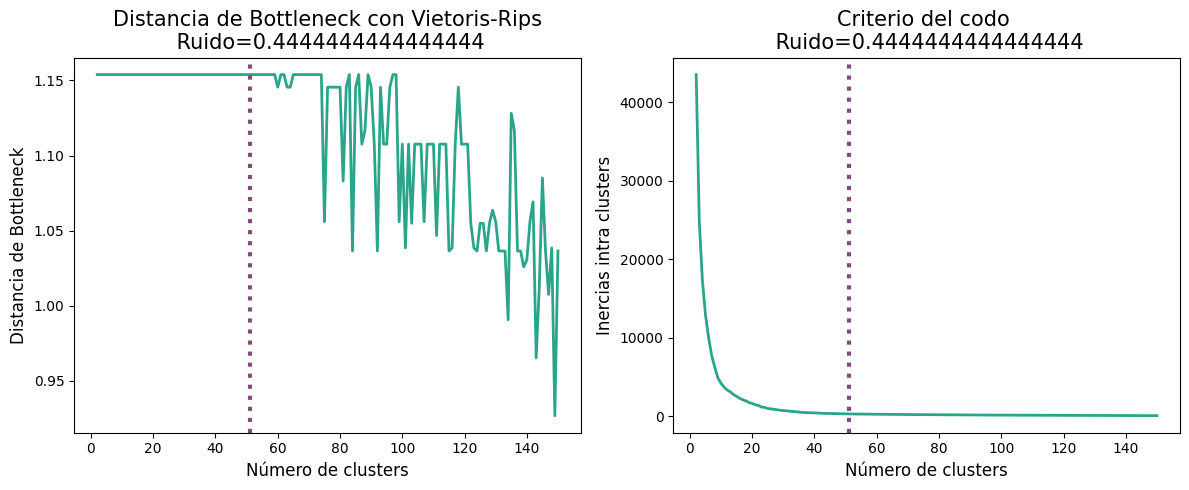

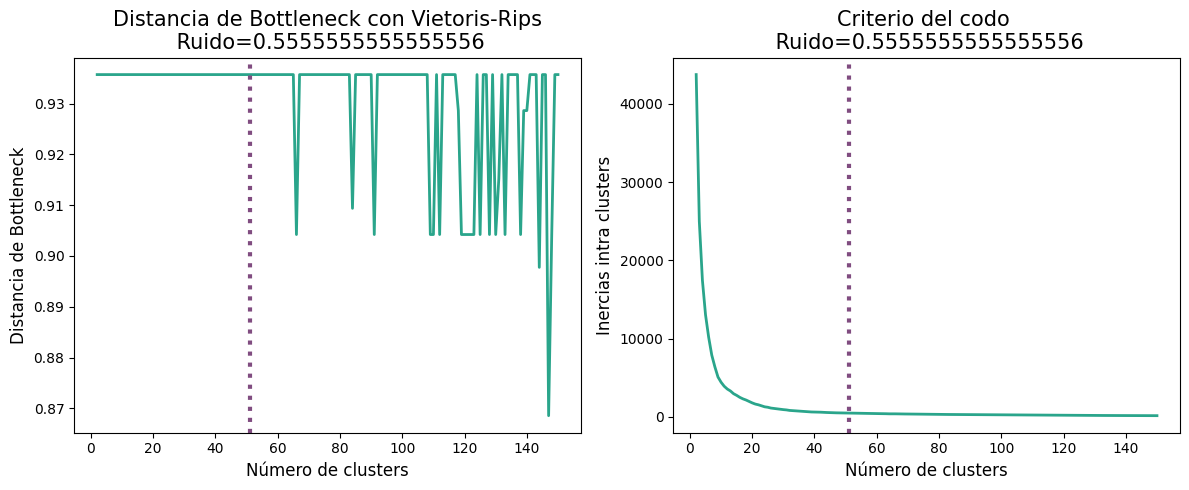

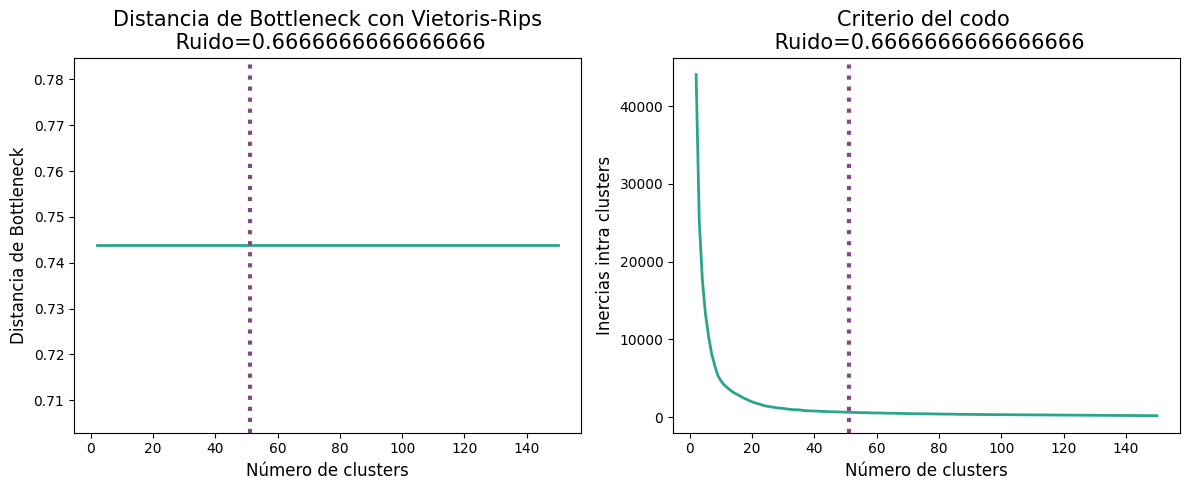

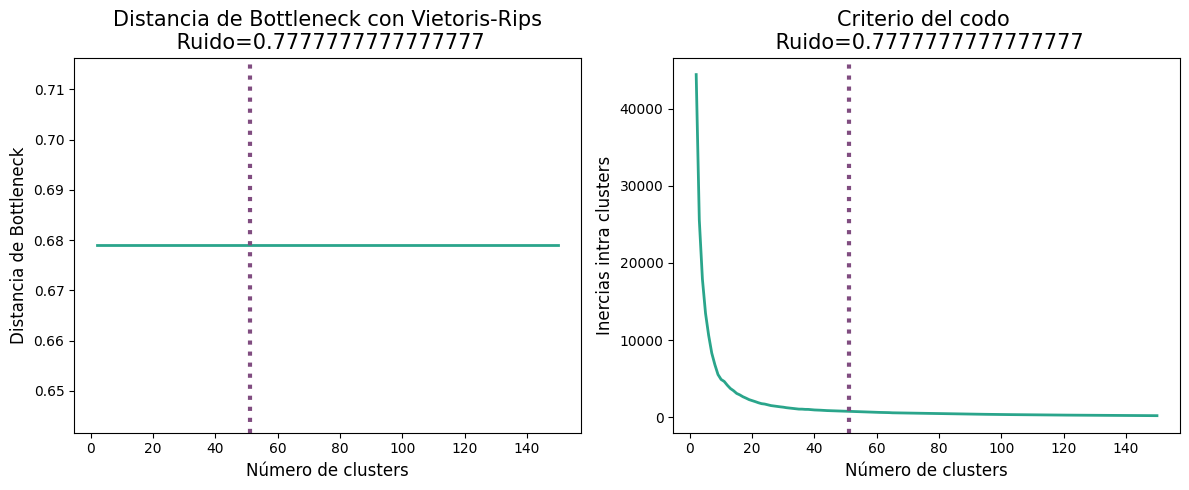

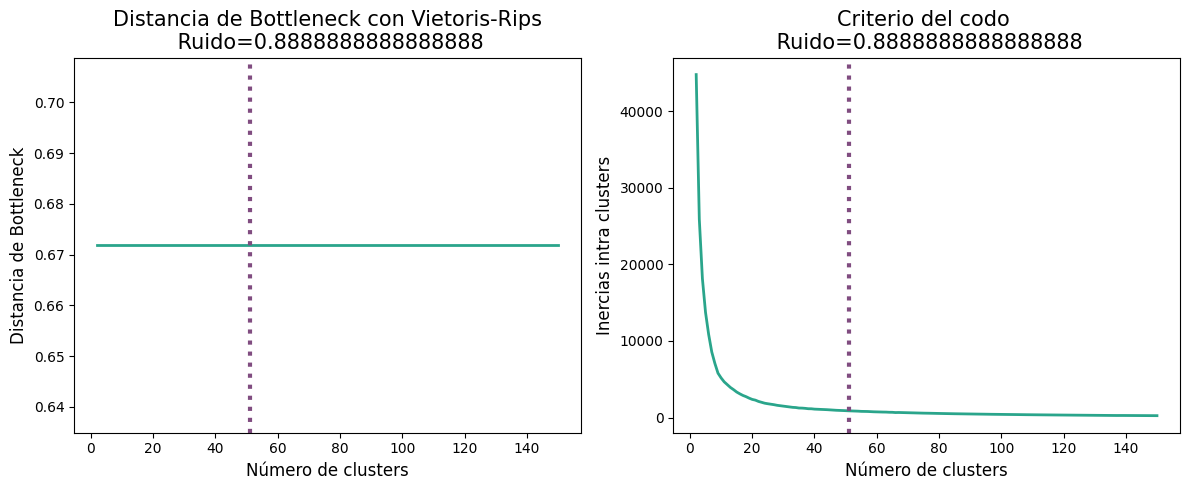

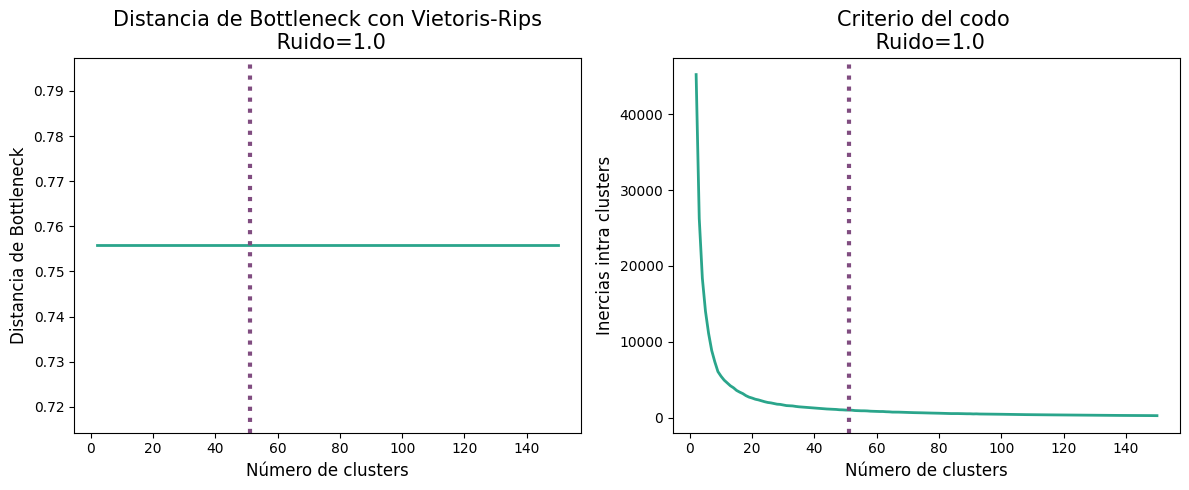

In [11]:
num_pruebas=10
num_clusters=51
num_puntos=1000
max_k = 150
ruido=np.linspace(0,1,num_pruebas)

for j in range(len(ruido)): 

    Datos,y=make_blobs(n_samples=num_puntos, centers=num_clusters, n_features=2, random_state=5, cluster_std=ruido[j])

    X=Datos
    inercias = []
    bottleneck_dists = []
    prev_diag = None

    AC=gd.RipsComplex(points=Datos, max_edge_length=200.0)
    alpha_simplex_tree = AC.create_simplex_tree()
    diag_alpha = alpha_simplex_tree.persistence()
    dim0_alpha = alpha_simplex_tree.persistence_intervals_in_dimension(0)
    
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        landmarks = kmeans.cluster_centers_
        inercias.append(kmeans.inertia_)
        
        dist_matrix = distance_matrix(landmarks, Datos)
        gudhi_table = []
        for t in range(dist_matrix.shape[1]):
            distances_to_witness = dist_matrix[:, t]
            
            witness_entries = [
                (idx, dist) for idx, dist in enumerate(distances_to_witness)
            ]

            witness_entries.sort(key=lambda x: x[1])
            gudhi_table.append(witness_entries)

        Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
        simplex_tree = Wt.create_simplex_tree(max_alpha_square=200, limit_dimension=1)
            
        diag = simplex_tree.persistence()
        aux = simplex_tree.persistence_intervals_in_dimension(0) 
            
        dist_b = gd.bottleneck_distance(dim0_alpha, aux)
        bottleneck_dists.append(dist_b)
        
        # if prev_diag is not None:
        #     dist_b = gd.bottleneck_distance(prev_diag, aux)
        #     bottleneck_dists.append(dist_b)
        
        # prev_diag = aux
        
    plt.figure(figsize=(12, 5))  # Ancho 12 pulgadas, alto 5 pulgadas

    # sumas_dist=[]
    # sumas_dist_prev=0
    # for i in range(0,len(bottleneck_dists)):
    #     aux=sumas_dist_prev+bottleneck_dists[i]
    #     sumas_dist_prev=aux
    #     sumas_dist.append(aux)

    plt.subplot(1,2,1)
    # plt.plot(list(range(3, max_k+1)), sumas_dist)
    plt.plot(list(range(2, max_k+1)), bottleneck_dists, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Distancia de Bottleneck con Vietoris-Rips\n Ruido={ruido[j]}', fontsize=15)  
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
    plt.subplot(1,2,2)
    plt.plot(list(range(2, max_k+1)), inercias, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Criterio del codo \n Ruido={ruido[j]}', fontsize=15)
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Inercias intra clusters', fontsize=12)
    
    plt.tight_layout()  
    plt.savefig(f"Witness_{j}_Vietoris.png", dpi=300, bbox_inches='tight')
    plt.show()

# **Comparación con Complejos Alpha**

/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (52). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (53). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (54). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (51) found smaller than n_clusters (55). Possibly due to duplicate points in X.
  return fit_method(estimato

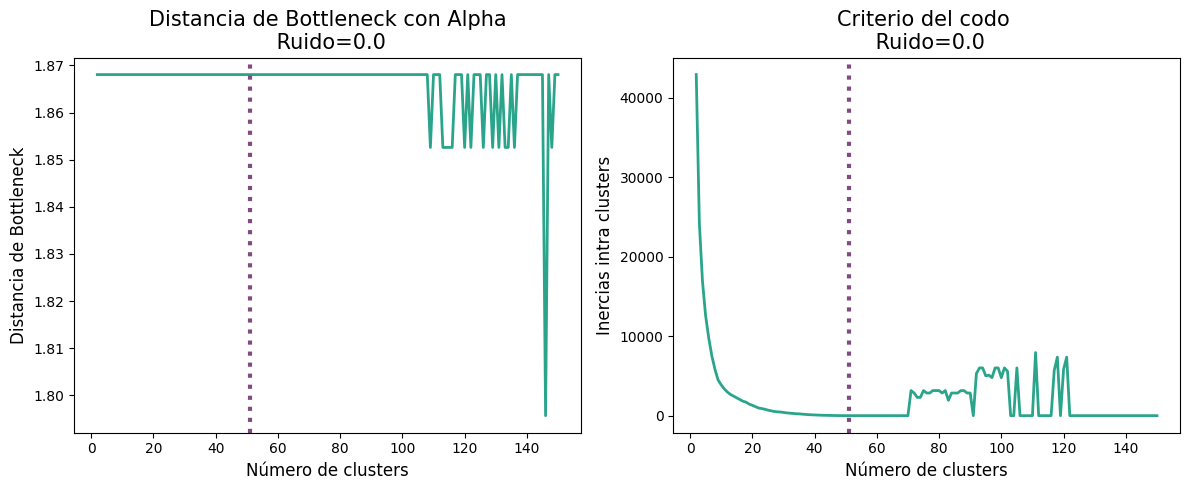

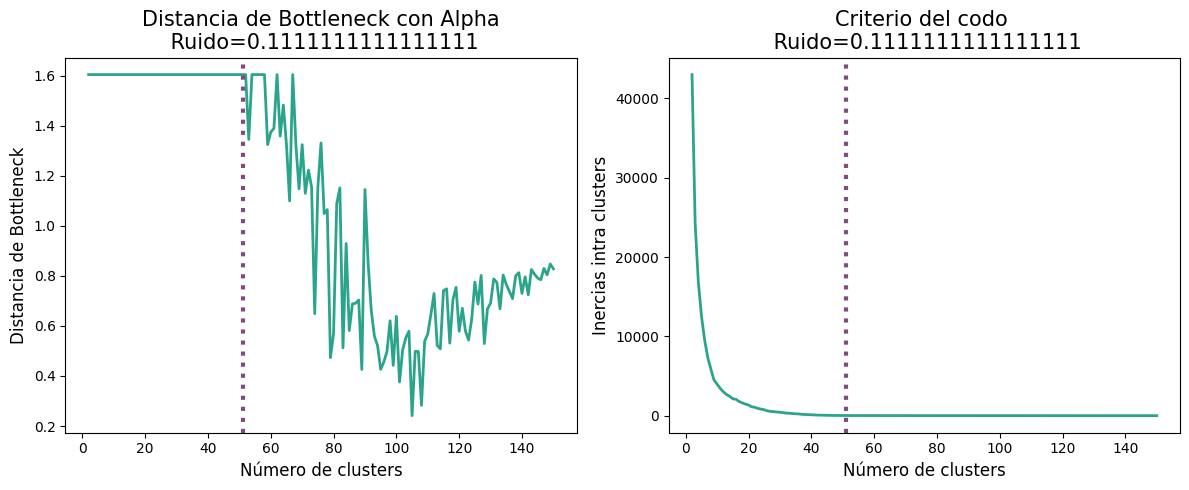

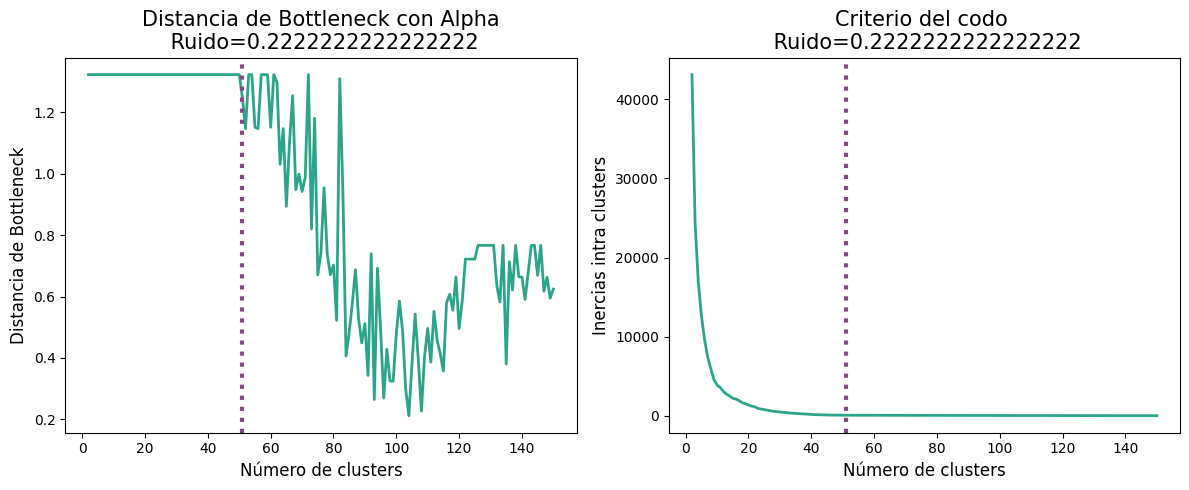

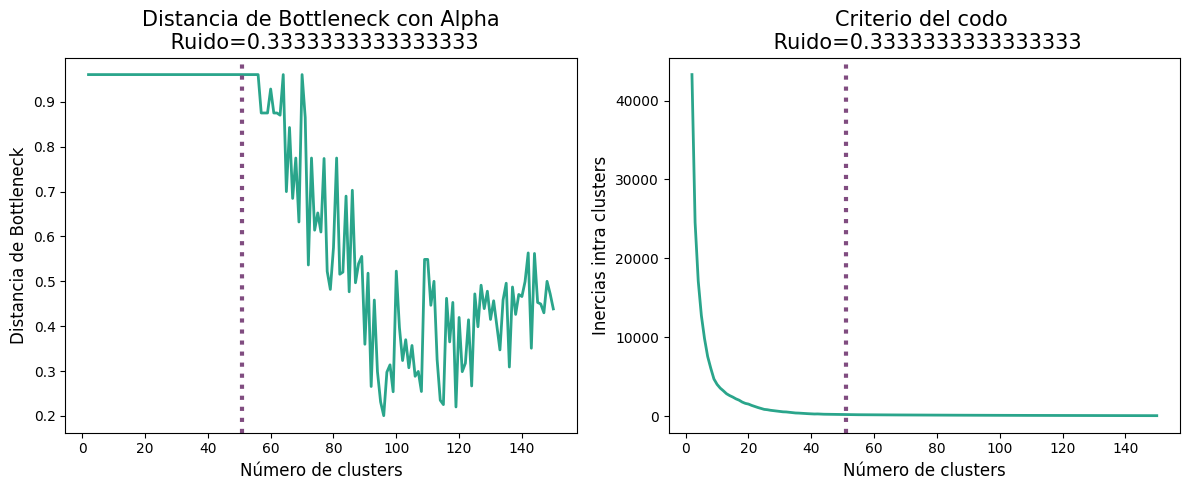

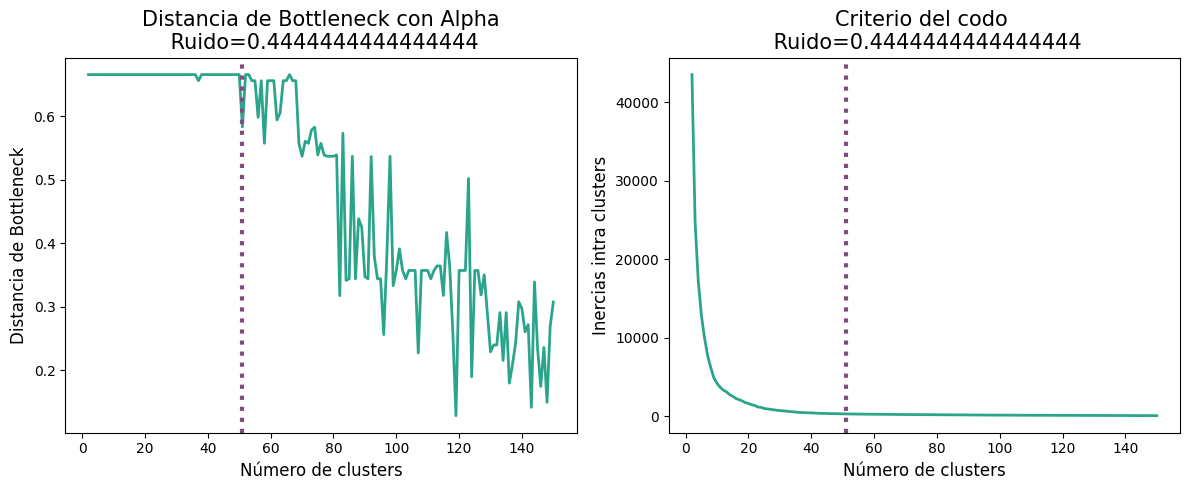

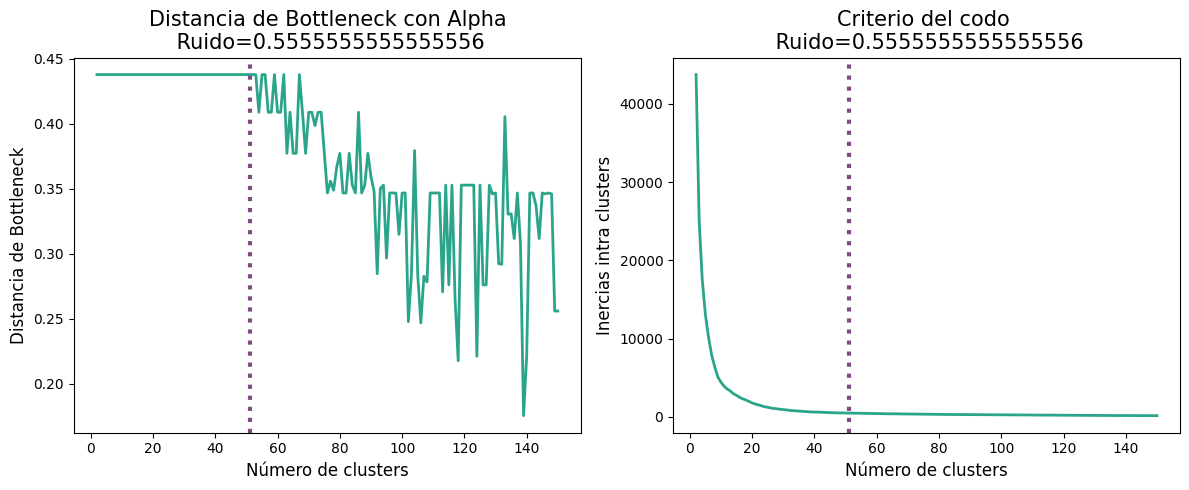

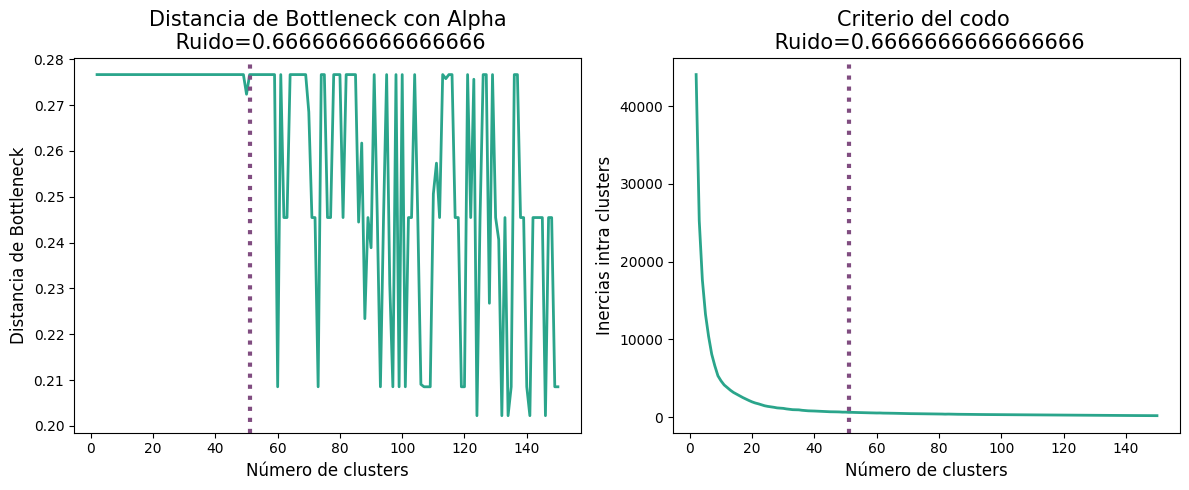

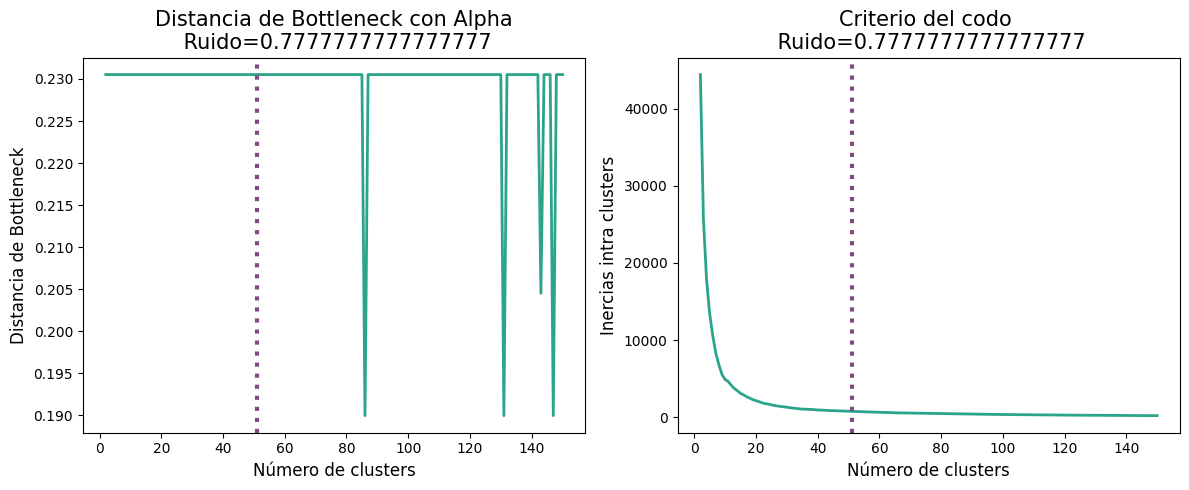

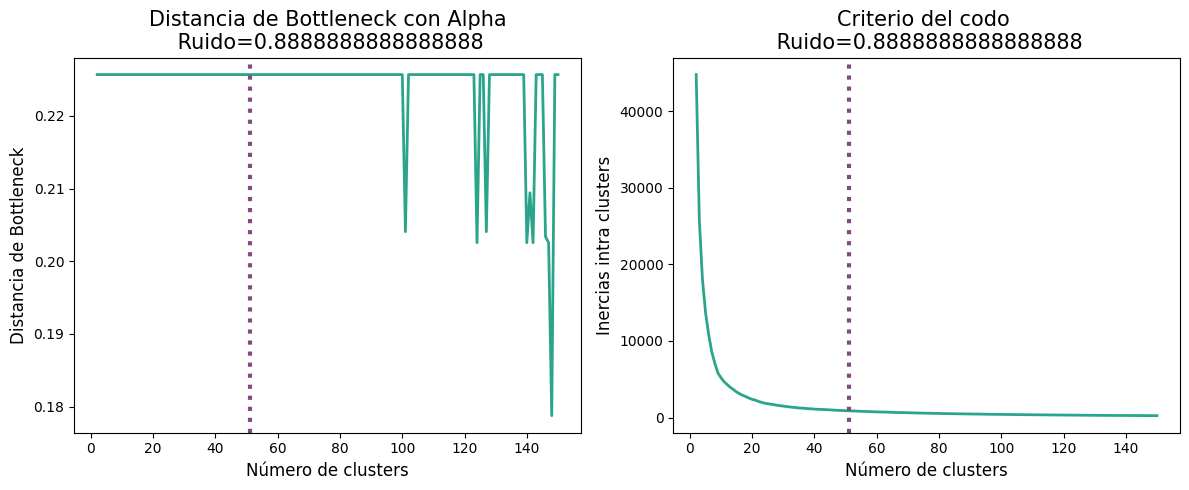

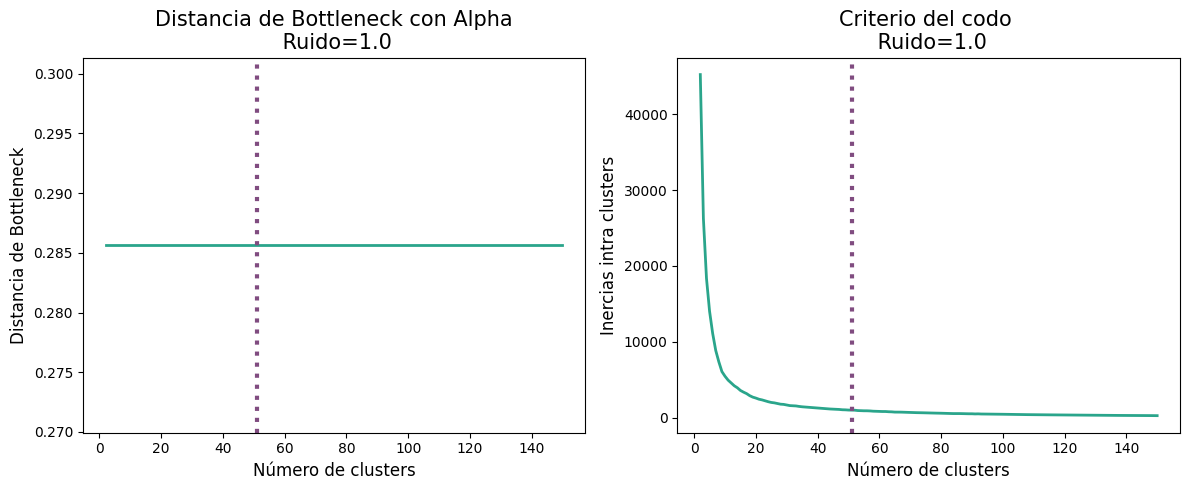

In [9]:
num_pruebas=10
num_clusters=51
num_puntos=1000
max_k = 150
ruido=np.linspace(0,1,num_pruebas)

for j in range(len(ruido)): 

    Datos,y=make_blobs(n_samples=num_puntos, centers=num_clusters, n_features=2, random_state=5, cluster_std=ruido[j])

    X=Datos
    inercias = []
    bottleneck_dists = []
    prev_diag = None

    AC=gd.AlphaComplex(Datos)
    alpha_simplex_tree = AC.create_simplex_tree(max_alpha_square=50)
    diag_alpha = alpha_simplex_tree.persistence()
    dim0_alpha = alpha_simplex_tree.persistence_intervals_in_dimension(0)
    
    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        landmarks = kmeans.cluster_centers_
        inercias.append(kmeans.inertia_)
        
        dist_matrix = distance_matrix(landmarks, Datos)
        gudhi_table = []
        for t in range(dist_matrix.shape[1]):
            distances_to_witness = dist_matrix[:, t]
            
            witness_entries = [
                (idx, dist) for idx, dist in enumerate(distances_to_witness)
            ]

            witness_entries.sort(key=lambda x: x[1])
            gudhi_table.append(witness_entries)

        Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
        simplex_tree = Wt.create_simplex_tree(max_alpha_square=200, limit_dimension=1)
            
        diag = simplex_tree.persistence()
        aux = simplex_tree.persistence_intervals_in_dimension(0) 
            
        dist_b = gd.bottleneck_distance(dim0_alpha, aux)
        bottleneck_dists.append(dist_b)
        
        # if prev_diag is not None:
        #     dist_b = gd.bottleneck_distance(prev_diag, aux)
        #     bottleneck_dists.append(dist_b)
        
        # prev_diag = aux
        
    plt.figure(figsize=(12, 5))  # Ancho 12 pulgadas, alto 5 pulgadas

    # sumas_dist=[]
    # sumas_dist_prev=0
    # for i in range(0,len(bottleneck_dists)):
    #     aux=sumas_dist_prev+bottleneck_dists[i]
    #     sumas_dist_prev=aux
    #     sumas_dist.append(aux)

    plt.subplot(1,2,1)
    # plt.plot(list(range(3, max_k+1)), sumas_dist)
    plt.plot(list(range(2, max_k+1)), bottleneck_dists, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Distancia de Bottleneck con Alpha\n Ruido={ruido[j]}', fontsize=15)  
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
    plt.subplot(1,2,2)
    plt.plot(list(range(2, max_k+1)), inercias, color='#2AA58B', linewidth=2)
    plt.axvline(num_clusters, color='#804C80', linewidth=3, linestyle=':')
    plt.title(f'Criterio del codo \n Ruido={ruido[j]}', fontsize=15)
    plt.xlabel('Número de clusters', fontsize=12)
    plt.ylabel('Inercias intra clusters', fontsize=12)
    
    plt.tight_layout()  
    plt.savefig(f"Witness_Alpha_{j}.png", dpi=300, bbox_inches='tight')
    plt.show()